In [2]:
%pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

optional arguments:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug

In [5]:
# Notebook completo: Comparativo de Modelos para Previsão de Energia Eólica no RS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon

import shap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
# === CARGA E PREPROCESSAMENTO DOS DADOS ===
def carregar_e_preparar_dados_es(caminho_excel):
    df = pd.read_excel(caminho_excel)
    df = df.rename(columns={"data_hora": "datetime"})
    df = df[df["vento_velocidade"] > 3.6].dropna().sort_values("datetime").reset_index(drop=True)
    return df

In [37]:
# === CONSTRUÇÃO DO DATASET COM LAGS ===
def criar_dataset_lags_es(df, horizon_horas=1, lags=[1, 2, 3]):
    passo_por_hora = 4
    horizon = horizon_horas * passo_por_hora
    features = ['temperatura_inst', 'umidade_inst', 'ponto_orvalho_inst',
                'pressao_inst', 'vento_velocidade', 'vento_direcao', 'precipitacao']
    X, y = [], []
    for i in range(max(lags), len(df) - horizon):
        linha = []
        for lag in lags:
            linha.extend(df.iloc[i - lag][features].values)
        X.append(linha)
        y.append(df.iloc[i + horizon]['potencia_gerada'])
    return np.array(X), np.array(y)

In [38]:
# === AVALIAÇÃO TEMPORAL COM BOXPLOT ===
def avaliar_modelo_interfold(modelo, X, y, k=5, nome_modelo="Modelo"):
    tscv = TimeSeriesSplit(n_splits=k)
    metricas = {'R2': [], 'MAE': [], 'RMSE': []}
    preds_all, trues_all = [], []
    for train_idx, test_idx in tscv.split(X):
        modelo.fit(X[train_idx], y[train_idx])
        y_pred = modelo.predict(X[test_idx])
        y_true = y[test_idx]
        preds_all.extend(y_pred)
        trues_all.extend(y_true)
        metricas['R2'].append(r2_score(y_true, y_pred))
        metricas['MAE'].append(mean_absolute_error(y_true, y_pred))
        metricas['RMSE'].append(np.sqrt(mean_squared_error(y_true, y_pred)))
    for metrica in metricas:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=metricas[metrica])
        plt.title(f"{nome_modelo} - {metrica} por Fold")
        plt.ylabel(metrica)
        plt.xlabel("Fold")
        plt.show()
    resumo = {m: (np.mean(vals), np.std(vals)) for m, vals in metricas.items()}
    return resumo, metricas, trues_all, preds_all

In [39]:
def exportar_resultados_para_csv(resultados_dict, nome_arquivo_prefixo="resultados"):
    linhas = []
    for modelo, resultados in resultados_dict.items():
        for h, info in resultados.items():
            r2, std_r2 = info['resumo']['R2']
            mae, std_mae = info['resumo']['MAE']
            rmse, std_rmse = info['resumo']['RMSE']
            tempo = info['resumo'].get('Tempo', None)
            linhas.append({
                'Modelo': modelo,
                'Horizonte': h,
                'R2': r2,
                'R2_std': std_r2,
                'MAE': mae,
                'MAE_std': std_mae,
                'RMSE': rmse,
                'RMSE_std': std_rmse,
                'Tempo (s)': tempo
            })
    df_resultados = pd.DataFrame(linhas)
    arquivo = f"{nome_arquivo_prefixo}_metricas.csv"
    df_resultados.to_csv(arquivo, index=False)
    print(f"✅ Resultados exportados para {arquivo}")
    return df_resultados


In [40]:
# 1. Carregar e preparar os dados
caminho_excel = "dfes.xlsx"
df_es = carregar_e_preparar_dados_es(caminho_excel)

# Arvores

In [49]:
import time  # Certifique-se de ter isso no topo do notebook

def rodar_modelos_arvore_es(df_es):
    modelos = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
    }
    resultados = {}
    for nome, modelo in modelos.items():
        resultados[nome] = {}
        for h in range(1, 7):
            print(f"\n--- {nome} - Horizonte {h}h ---")
            X, y = criar_dataset_lags_es(df_es, horizon_horas=h)
            if len(X) < 20:
                print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
                continue

            split = int(0.8 * len(X))
            X_train, y_train = X[:split], y[:split]
            X_test, y_test = X[split:], y[split:]

            start_time = time.time()
            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            elapsed = time.time() - start_time

            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

            resultados[nome][h] = {
                'resumo': {
                    'R2': (r2, 0),
                    'MAE': (mae, 0),
                    'RMSE': (rmse, 0),
                    'Tempo': elapsed
                },
                'metricas_fold': {
                    'R2': [r2],
                    'MAE': [mae],
                    'RMSE': [rmse]
                },
                'y_true': y_test.tolist(),
                'y_pred': y_pred.tolist()
            }

    return resultados


# Tempo de execucao das arvores

In [51]:
def plotar_tempo_execucao(df_resultados):
    import matplotlib.pyplot as plt
    import seaborn as sns

    if 'Tempo (s)' not in df_resultados.columns:
        print("⛔ Coluna 'Tempo (s)' não encontrada no DataFrame.")
        return

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_resultados,
        x="Horizonte",
        y="Tempo (s)",
        hue="Modelo",
        marker="o"
    )
    plt.title("Tempo de Execução por Modelo e Horizonte de Previsão")
    plt.xlabel("Horizonte (h)")
    plt.ylabel("Tempo (segundos)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# MLP

In [52]:
import time

def rodar_mlp_es(df_es):
    resultados_mlp = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- MLP - Horizonte {h}h ---")
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        modelo = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                              learning_rate='adaptive', max_iter=500, random_state=42)

        start = time.time()
        resumo, metricas, y_true, y_pred = avaliar_modelo_interfold(modelo, X, y, k=5, nome_modelo=f"MLP - {h}h")
        elapsed = time.time() - start

        # Adicionar tempo ao resumo
        resumo['Tempo'] = elapsed

        print(f"Horizonte {h}h - Tempo: {elapsed:.2f}s")
        resultados_mlp[h] = {
            'resumo': resumo,
            'metricas_fold': metricas,
            'y_true': y_true,
            'y_pred': y_pred
        }

        maes.append(resumo['MAE'][0])
        rmses.append(resumo['RMSE'][0])
        r2s.append(resumo['R2'][0])
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do MLP por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_mlp


# LSTM

In [53]:
# === LSTM COM AJUSTES DE TREINO ===
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

def rodar_lstm_es(df_es):
    resultados_lstm = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- LSTM - Horizonte {h}h ---")
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue
        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]
        scaler = StandardScaler()
        X_train_flat = X_train.reshape(-1, n_features)
        X_test_flat = X_test.reshape(-1, n_features)
        X_train_flat = scaler.fit_transform(X_train_flat)
        X_test_flat = scaler.transform(X_test_flat)
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = LSTMRegressor(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                out = model(batch_X)
                loss = loss_fn(out, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss/len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")
        resultados_lstm[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0)},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do LSTM por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Nenhum horizonte foi avaliado devido à falta de dados.")

     # Gráfico real vs previsto (amostras do último horizonte)
        plt.figure(figsize=(8, 4))
        plt.plot(y_test[:100], label='Real')
        plt.plot(preds[:100], label='Previsto')
        plt.title(f"Previsão LSTM - Horizonte {h}h")
        plt.xlabel("Amostras")
        plt.ylabel("Potência")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return resultados_lstm


In [ ]:
resultados_lstm = rodar_lstm_es(df_es)

In [ ]:
# Show results table
mostrar_tabela_resultados(exportar_resultados_para_csv({"LSTM": resultados_lstm}, "es_lstm"))

# GRU

In [54]:
# === GRU COM AJUSTES DE TREINO ===
class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h[-1])

def rodar_gru_es(df_es):
    resultados_gru = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- GRU - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        # Preparação dos dados
        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

        # Modelo
        model = GRURegressor(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_gru[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do GRU por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_gru

In [ ]:
# Execute GRU model and store results
resultados_gru = rodar_gru_es(df_es)

# Show results table
mostrar_tabela_resultados(exportar_resultados_para_csv({"GRU": resultados_lstm}, "es_gru"))

#TCN

In [55]:
# === TCN COM AJUSTES DE TREINO ===
class TCNBlock(nn.Module):
    def __init__(self, input_size, hidden_size=64, kernel_size=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_size, hidden_size, kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(hidden_size, hidden_size, kernel_size, padding=1)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = torch.mean(x, dim=2)
        return self.fc(x)

def rodar_tcn_es(df_es):
    resultados_tcn = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- TCN - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

        model = TCNBlock(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_tcn[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do TCN por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_tcn

# Transformer

In [56]:
# === TRANSFORMER COM AJUSTES DE TREINO ===
class TransformerBlock(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

def rodar_transformer_es(df_es):
    resultados_transf = {}
    maes, rmses, r2s, hs = [], [], [], []
    import time  # importar no topo do notebook se necessário
    for h in range(1, 7):
        start_time = time.time()
        print(f"\n--- Transformer - Horizonte {h}h ---")
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue
        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]
        scaler = StandardScaler()
        X_train_flat = X_train.reshape(-1, n_features)
        X_test_flat = X_test.reshape(-1, n_features)
        X_train_flat = scaler.fit_transform(X_train_flat)
        X_test_flat = scaler.transform(X_test_flat)
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = TransformerBlock(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                out = model(batch_X)
                loss = loss_fn(out, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss/len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        elapsed = time.time() - start_time
        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")
        resultados_transf[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do Transformer por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Nenhum horizonte foi avaliado devido à falta de dados.")

    # Gráfico real vs previsto (amostras do último horizonte)
        plt.figure(figsize=(8, 4))
        plt.plot(y_test[:100], label='Real')
        plt.plot(preds[:100], label='Previsto')
        plt.title(f"Previsão Transformer - Horizonte {h}h")
        plt.xlabel("Amostras")
        plt.ylabel("Potência")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return resultados_transf



--- Random Forest - Horizonte 1h ---
Horizonte 1h - R2: 0.550, MAE: 44.19, RMSE: 61.61, Tempo: 17.45s

--- Random Forest - Horizonte 2h ---
Horizonte 2h - R2: 0.402, MAE: 50.93, RMSE: 71.00, Tempo: 16.97s

--- Random Forest - Horizonte 3h ---
Horizonte 3h - R2: 0.338, MAE: 54.01, RMSE: 74.69, Tempo: 17.45s

--- Random Forest - Horizonte 4h ---
Horizonte 4h - R2: 0.337, MAE: 55.29, RMSE: 74.76, Tempo: 17.07s

--- Random Forest - Horizonte 5h ---
Horizonte 5h - R2: 0.330, MAE: 56.70, RMSE: 75.15, Tempo: 17.55s

--- Random Forest - Horizonte 6h ---
Horizonte 6h - R2: 0.251, MAE: 60.09, RMSE: 79.51, Tempo: 17.36s

--- Gradient Boosting - Horizonte 1h ---
Horizonte 1h - R2: 0.572, MAE: 42.89, RMSE: 60.10, Tempo: 4.16s

--- Gradient Boosting - Horizonte 2h ---
Horizonte 2h - R2: 0.437, MAE: 49.46, RMSE: 68.88, Tempo: 4.26s

--- Gradient Boosting - Horizonte 3h ---
Horizonte 3h - R2: 0.374, MAE: 52.25, RMSE: 72.65, Tempo: 4.22s

--- Gradient Boosting - Horizonte 4h ---
Horizonte 4h - R2: 0.3

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


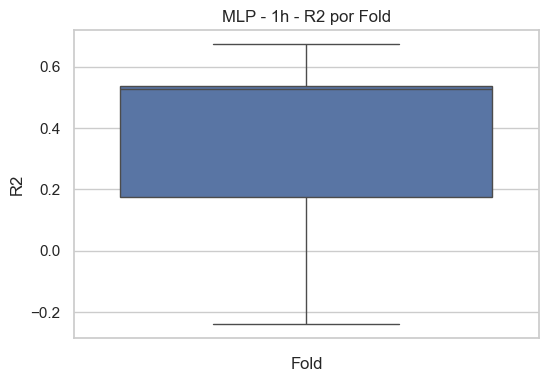

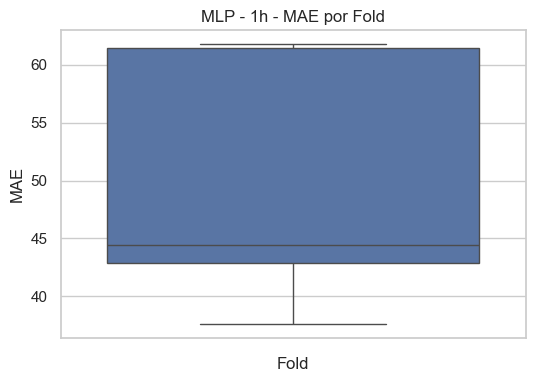

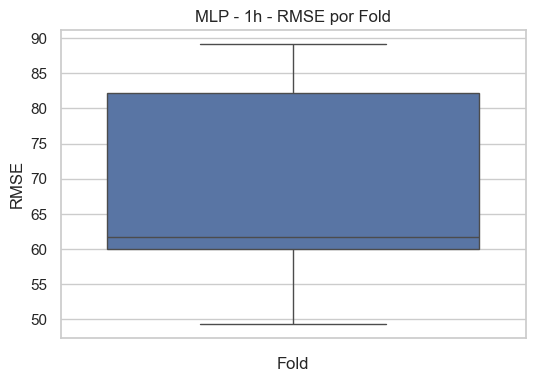

Horizonte 1h - Tempo: 357.21s

--- MLP - Horizonte 2h ---


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


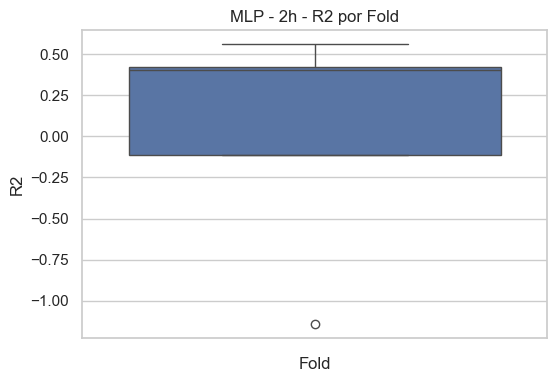

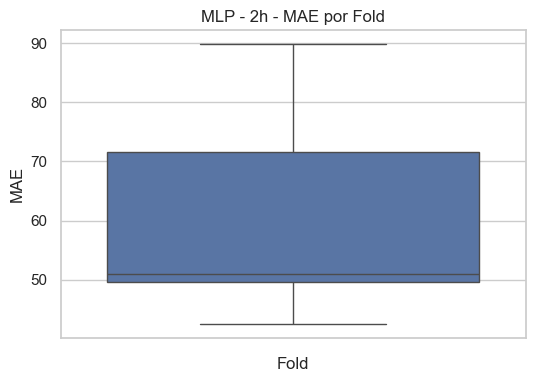

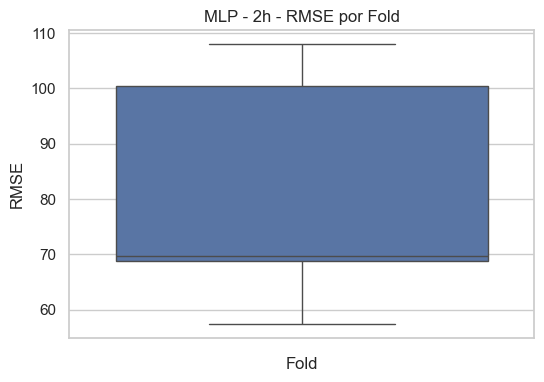

Horizonte 2h - Tempo: 187.90s

--- MLP - Horizonte 3h ---


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


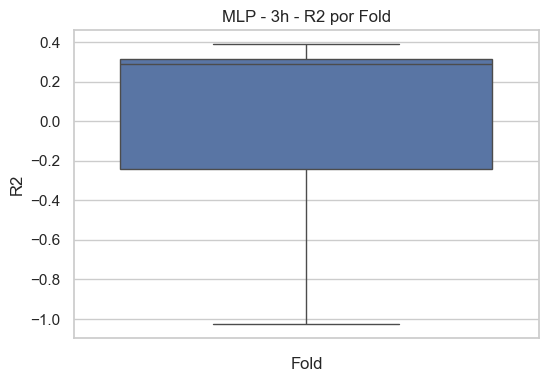

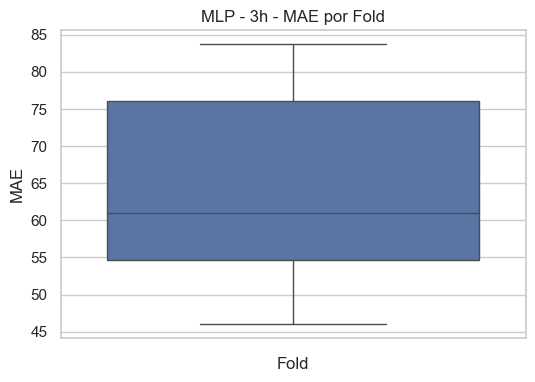

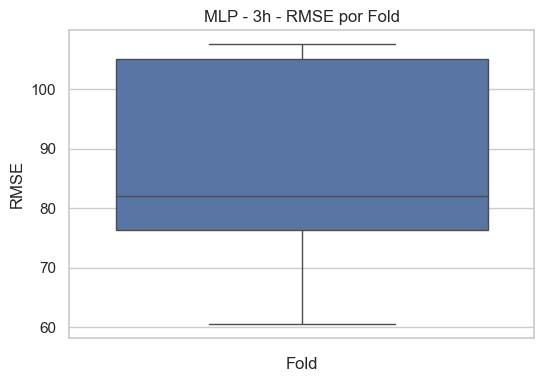

Horizonte 3h - Tempo: 323.77s

--- MLP - Horizonte 4h ---


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_

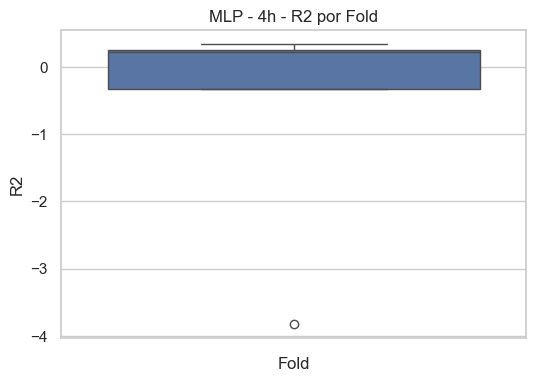

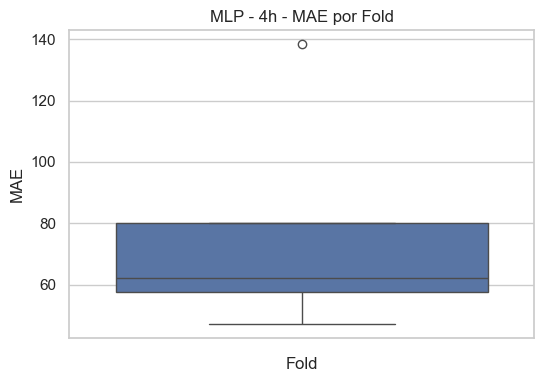

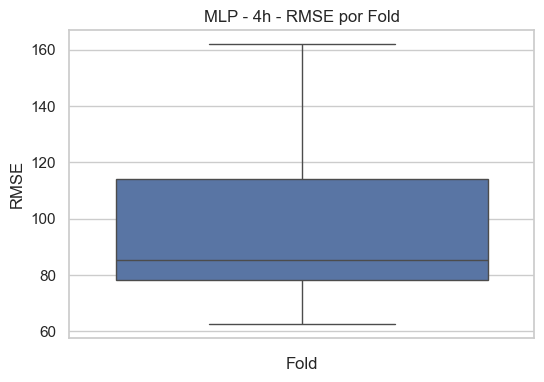

Horizonte 4h - Tempo: 260.01s

--- MLP - Horizonte 5h ---


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_

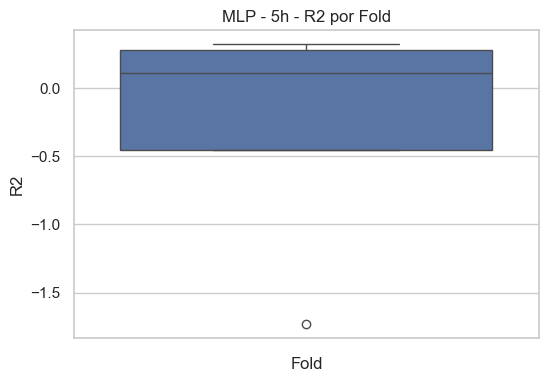

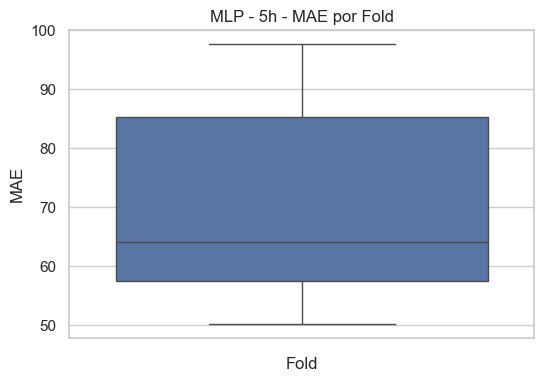

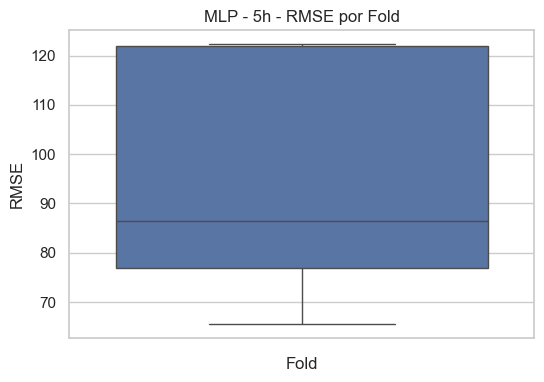

Horizonte 5h - Tempo: 398.43s

--- MLP - Horizonte 6h ---


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_

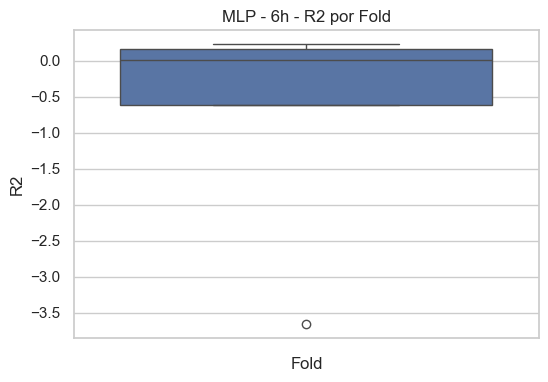

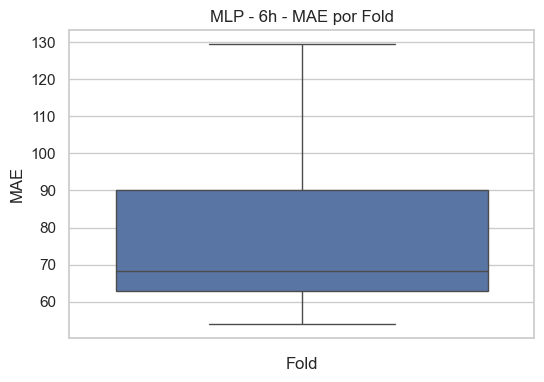

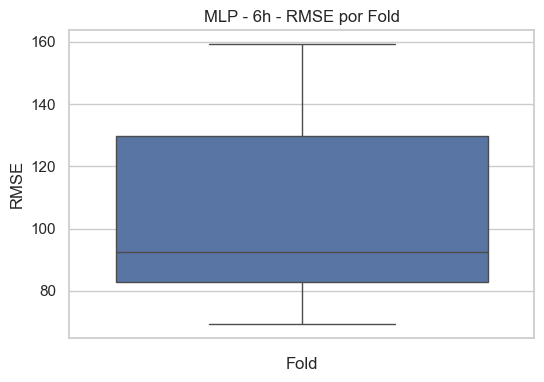

Horizonte 6h - Tempo: 409.17s


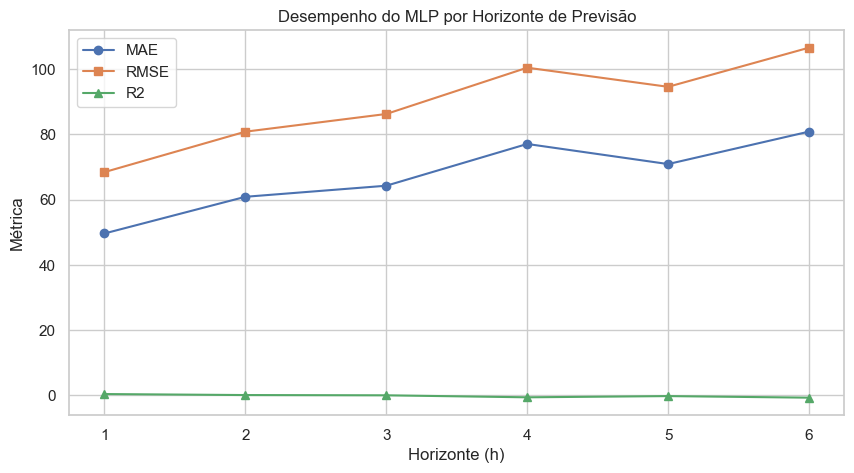


--- LSTM - Horizonte 1h ---
Tamanho do dataset para 1h: 18632 amostras
Epoch 0 - Loss: 16329.9174
Epoch 50 - Loss: 2548.2015
Epoch 100 - Loss: 2011.3064
Epoch 150 - Loss: 1583.9493
Epoch 200 - Loss: 1260.5956
Epoch 250 - Loss: 1022.1731
Horizonte 1h - R2: 0.440, MAE: 50.35, RMSE: 68.72

--- LSTM - Horizonte 2h ---
Tamanho do dataset para 2h: 18628 amostras
Epoch 0 - Loss: 16285.1074
Epoch 50 - Loss: 3092.0344
Epoch 100 - Loss: 2321.6876
Epoch 150 - Loss: 1793.0042
Epoch 200 - Loss: 1403.0062
Epoch 250 - Loss: 1118.9545
Horizonte 2h - R2: 0.173, MAE: 60.44, RMSE: 83.51

--- LSTM - Horizonte 3h ---
Tamanho do dataset para 3h: 18624 amostras
Epoch 0 - Loss: 16216.6175
Epoch 50 - Loss: 3642.0464
Epoch 100 - Loss: 2766.5734
Epoch 150 - Loss: 2098.4426
Epoch 200 - Loss: 1604.2103
Epoch 250 - Loss: 1261.0948
Horizonte 3h - R2: 0.102, MAE: 61.94, RMSE: 86.99

--- LSTM - Horizonte 4h ---
Tamanho do dataset para 4h: 18620 amostras
Epoch 0 - Loss: 16219.0463
Epoch 50 - Loss: 4009.5935
Epoch 100 

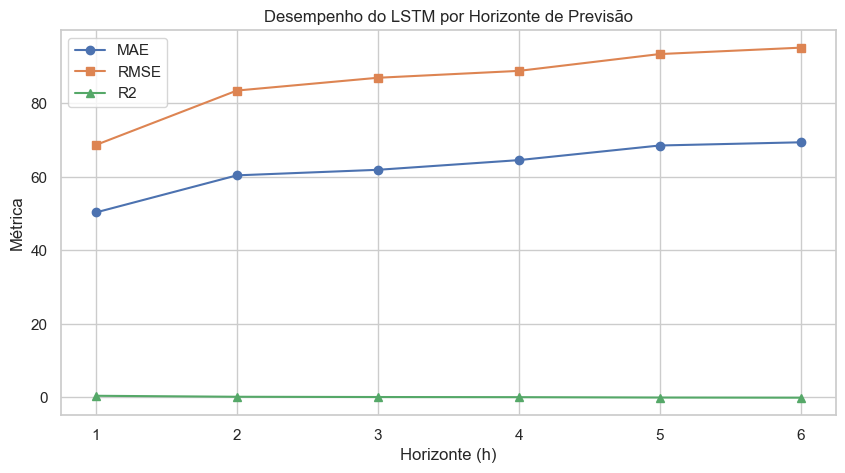


--- GRU - Horizonte 1h ---
Tamanho do dataset para 1h: 18632 amostras
Epoch 0 - Loss: 16244.8138
Epoch 50 - Loss: 2355.4486
Epoch 100 - Loss: 1668.8380
Epoch 150 - Loss: 1227.8341
Epoch 200 - Loss: 939.8889
Epoch 250 - Loss: 756.7193
Horizonte 1h - R2: 0.389, MAE: 51.69, RMSE: 71.77, Tempo: 178.77s

--- GRU - Horizonte 2h ---
Tamanho do dataset para 2h: 18628 amostras
Epoch 0 - Loss: 16348.8208
Epoch 50 - Loss: 2843.9131
Epoch 100 - Loss: 2002.8725
Epoch 150 - Loss: 1490.0944
Epoch 200 - Loss: 1142.3798
Epoch 250 - Loss: 910.7908
Horizonte 2h - R2: 0.179, MAE: 60.75, RMSE: 83.21, Tempo: 177.65s

--- GRU - Horizonte 3h ---
Tamanho do dataset para 3h: 18624 amostras
Epoch 0 - Loss: 16200.2288
Epoch 50 - Loss: 3266.6100
Epoch 100 - Loss: 2127.6005
Epoch 150 - Loss: 1492.7779
Epoch 200 - Loss: 1121.7352
Epoch 250 - Loss: 884.2716
Horizonte 3h - R2: 0.077, MAE: 64.50, RMSE: 88.21, Tempo: 178.92s

--- GRU - Horizonte 4h ---
Tamanho do dataset para 4h: 18620 amostras
Epoch 0 - Loss: 16254.17

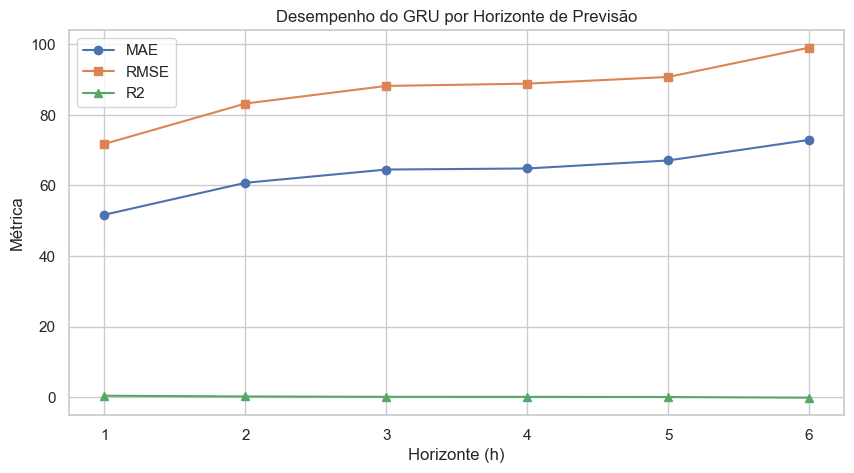


--- TCN - Horizonte 1h ---
Tamanho do dataset para 1h: 18632 amostras
Epoch 0 - Loss: 7754.8211
Epoch 50 - Loss: 2790.5135
Epoch 100 - Loss: 2643.8722
Epoch 150 - Loss: 2530.3897
Epoch 200 - Loss: 2406.4236
Epoch 250 - Loss: 2330.5003
Horizonte 1h - R2: 0.552, MAE: 44.54, RMSE: 61.47, Tempo: 487.23s

--- TCN - Horizonte 2h ---
Tamanho do dataset para 2h: 18628 amostras
Epoch 0 - Loss: 8346.3111
Epoch 50 - Loss: 3639.5832
Epoch 100 - Loss: 3364.8076
Epoch 150 - Loss: 3212.0810
Epoch 200 - Loss: 3080.4211
Epoch 250 - Loss: 2978.3461
Horizonte 2h - R2: 0.369, MAE: 53.70, RMSE: 72.96, Tempo: 552.39s

--- TCN - Horizonte 3h ---
Tamanho do dataset para 3h: 18624 amostras
Epoch 0 - Loss: 8784.0756
Epoch 50 - Loss: 4262.5796
Epoch 100 - Loss: 3915.5267
Epoch 150 - Loss: 3712.2209
Epoch 200 - Loss: 3575.7472
Epoch 250 - Loss: 3449.8867
Horizonte 3h - R2: 0.278, MAE: 56.53, RMSE: 78.00, Tempo: 450.70s

--- TCN - Horizonte 4h ---
Tamanho do dataset para 4h: 18620 amostras
Epoch 0 - Loss: 9893.79

In [ ]:
resultados_todos = {}

# Árvores
df_es = carregar_e_preparar_dados_es("dfes.xlsx")
resultados_todos.update(rodar_modelos_arvore_es(df_es))

# Redes
resultados_todos["MLP"] = rodar_mlp_es(df_es)
resultados_todos["LSTM"] = rodar_lstm_es(df_es)
resultados_todos["GRU"] = rodar_gru_es(df_es)
resultados_todos["TCN"] = rodar_tcn_es(df_es)
resultados_todos["Transformer"] = rodar_transformer_es(df_es)


In [ ]:
df_resultados_todos = exportar_resultados_para_csv(resultados_todos, nome_arquivo_prefixo="todos_modelos_es")


In [ ]:
def graficos_comparativos_todos(df_resultados, metrica="RMSE"):
    import seaborn as sns
    import matplotlib.pyplot as plt

    if metrica not in ["RMSE", "MAE", "R2"]:
        print("Métrica inválida. Use: 'RMSE', 'MAE' ou 'R2'.")
        return

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_resultados,
        x="Horizonte",
        y=metrica,
        hue="Modelo",
        marker="o"
    )
    plt.title(f"{metrica} por Modelo e Horizonte")
    plt.xlabel("Horizonte (h)")
    plt.ylabel(metrica)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
graficos_comparativos_todos(df_resultados_todos, metrica="RMSE")
graficos_comparativos_todos(df_resultados_todos, metrica="MAE")
graficos_comparativos_todos(df_resultados_todos, metrica="R2")


In [ ]:
# === COMPARAÇÃO VISUAL ENTRE TODOS OS MODELOS ===
def graficos_comparativos_todos(resultados_dict, metrica="RMSE"):
    plt.figure(figsize=(10, 6))
    for modelo, resultados in resultados_dict.items():
        valores = [resultados[h]['resumo'][metrica][0] for h in range(1, 7) if h in resultados]
        plt.plot(range(1, 1+len(valores)), valores, marker='o', label=modelo)
    plt.title(f"Comparação de {metrica} por Modelo e Horizonte")
    plt.xlabel("Horizonte (h)")
    plt.ylabel(metrica)
    plt.legend()
    plt.grid(True)
    plt.show()

# === BOXPLOTS GERAIS POR MODELO E HORIZONTE ===
def boxplot_geral_metricas(resultados_dict, metrica="RMSE"):
    dados = []
    for modelo, resultados in resultados_dict.items():
        for h, valores in resultados.items():
            for v in valores['metricas_fold'][metrica]:
                dados.append({"Modelo": modelo, "Horizonte": h, metrica: v})
    df = pd.DataFrame(dados)
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Horizonte", y=metrica, hue="Modelo", data=df)
    plt.title(f"Boxplot de {metrica} por Modelo e Horizonte")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === TESTE DE SIGNIFICÂNCIA WILCOXON ENTRE MODELOS ===
def teste_significancia_modelos(resultados_dict, metrica="RMSE"):
    modelos = list(resultados_dict.keys())
    for h in range(1, 7):
        print(f"\n--- Teste Wilcoxon para horizonte {h}h ({metrica}) ---")
        for i in range(len(modelos)):
            for j in range(i+1, len(modelos)):
                m1, m2 = modelos[i], modelos[j]
                if h in resultados_dict[m1] and h in resultados_dict[m2]:
                    v1 = resultados_dict[m1][h]['metricas_fold'][metrica]
                    v2 = resultados_dict[m2][h]['metricas_fold'][metrica]
                    if len(v1) == len(v2):
                        try:
                            stat, p = wilcoxon(v1, v2)
                            sig = '*' if p < 0.05 else ''
                            print(f"{m1} vs {m2}: p={p:.4f} {sig}")
                        except ValueError as e:
                            print(f"{m1} vs {m2}: teste inválido ({e})")


# RS

## Funcoes ajustadas

In [ ]:
def carregar_e_preparar_dados_rs(caminho_excel):
    df = pd.read_excel(caminho_excel)
    df = df.rename(columns={"Data_Hora": "datetime"})
    df = df[df["vento_velocidade"] > 3.6].dropna().sort_values("datetime").reset_index(drop=True)
    return df


In [ ]:
def criar_dataset_lags_rs(df, horizon_horas=1, lags=[1, 2, 3]):
    features = ['temperatura_inst', 'umidade_inst', 'ponto_orvalho_inst',
                'pressao_inst', 'vento_velocidade', 'vento_direcao', 'precipitacao']
    X, y = [], []
    for i in range(max(lags), len(df) - horizon_horas):
        linha = []
        for lag in lags:
            linha.extend(df.iloc[i - lag][features].values)
        X.append(linha)
        y.append(df.iloc[i + horizon_horas]['potencia_gerada'])
    return np.array(X), np.array(y)


In [ ]:
# === AVALIAÇÃO TEMPORAL COM BOXPLOT ===
def avaliar_modelo_interfold(modelo, X, y, k=5, nome_modelo="Modelo"):
    tscv = TimeSeriesSplit(n_splits=k)
    metricas = {'R2': [], 'MAE': [], 'RMSE': []}
    preds_all, trues_all = [], []
    for train_idx, test_idx in tscv.split(X):
        modelo.fit(X[train_idx], y[train_idx])
        y_pred = modelo.predict(X[test_idx])
        y_true = y[test_idx]
        preds_all.extend(y_pred)
        trues_all.extend(y_true)
        metricas['R2'].append(r2_score(y_true, y_pred))
        metricas['MAE'].append(mean_absolute_error(y_true, y_pred))
        metricas['RMSE'].append(np.sqrt(mean_squared_error(y_true, y_pred)))
    for metrica in metricas:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=metricas[metrica])
        plt.title(f"{nome_modelo} - {metrica} por Fold")
        plt.ylabel(metrica)
        plt.xlabel("Fold")
        plt.show()
    resumo = {m: (np.mean(vals), np.std(vals)) for m, vals in metricas.items()}
    return resumo, metricas, trues_all, preds_all

In [ ]:
def exportar_resultados_para_csv(resultados_dict, nome_arquivo_prefixo="resultados"):
    linhas = []
    for modelo, resultados in resultados_dict.items():
        for h, info in resultados.items():
            r2, std_r2 = info['resumo']['R2']
            mae, std_mae = info['resumo']['MAE']
            rmse, std_rmse = info['resumo']['RMSE']
            tempo = info['resumo'].get('Tempo', None)
            linhas.append({
                'Modelo': modelo,
                'Horizonte': h,
                'R2': r2,
                'R2_std': std_r2,
                'MAE': mae,
                'MAE_std': std_mae,
                'RMSE': rmse,
                'RMSE_std': std_rmse,
                'Tempo (s)': tempo
            })
    df_resultados = pd.DataFrame(linhas)
    arquivo = f"{nome_arquivo_prefixo}_metricas.csv"
    df_resultados.to_csv(arquivo, index=False)
    print(f"✅ Resultados exportados para {arquivo}")
    return df_resultados

In [ ]:
# 1. Carregar e preparar os dados RS
caminho_excel = "dfrs.xlsx"
df_rs = carregar_e_preparar_dados_rs(caminho_excel)

In [ ]:
df_rs

## Modelos

### Arvores RS

In [ ]:
def rodar_modelos_arvore_rs(df_rs):
    modelos = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
    }
    resultados = {}
    for nome, modelo in modelos.items():
        resultados[nome] = {}
        for h in range(1, 7):
            print(f"\n--- {nome} - Horizonte {h}h ---")
            X, y = criar_dataset_lags_rs(df_rs, horizon_horas=h)
            if len(X) < 20:
                print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
                continue

            split = int(0.8 * len(X))
            X_train, y_train = X[:split], y[:split]
            X_test, y_test = X[split:], y[split:]

            start_time = time.time()
            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            elapsed = time.time() - start_time

            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

            resultados[nome][h] = {
                'resumo': {
                    'R2': (r2, 0),
                    'MAE': (mae, 0),
                    'RMSE': (rmse, 0),
                    'Tempo': elapsed
                },
                'metricas_fold': {
                    'R2': [r2],
                    'MAE': [mae],
                    'RMSE': [rmse]
                },
                'y_true': y_test.tolist(),
                'y_pred': y_pred.tolist()
            }

    return resultados


### MLP RS

In [ ]:
def rodar_mlp_rs(df_rs):
    resultados_mlp = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- MLP - Horizonte {h}h ---")
        X, y = criar_dataset_lags_rs(df_rs, horizon_horas=h, lags=[1, 2, 3])
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        modelo = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                              learning_rate='adaptive', max_iter=500, random_state=42)

        start = time.time()
        resumo, metricas, y_true, y_pred = avaliar_modelo_interfold(modelo, X, y, k=5, nome_modelo=f"MLP - {h}h")
        elapsed = time.time() - start

        # Adicionar tempo ao resumo
        resumo['Tempo'] = elapsed

        print(f"Horizonte {h}h - Tempo: {elapsed:.2f}s")
        resultados_mlp[h] = {
            'resumo': resumo,
            'metricas_fold': metricas,
            'y_true': y_true,
            'y_pred': y_pred
        }

        maes.append(resumo['MAE'][0])
        rmses.append(resumo['RMSE'][0])
        r2s.append(resumo['R2'][0])
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do MLP por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_mlp


### LSTM RS


In [ ]:
# === LSTM COM AJUSTES DE TREINO ===
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

def rodar_lstm_rs(df_rs):
    resultados_lstm = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- LSTM - Horizonte {h}h ---")
        X, y = criar_dataset_lags_rs(df_rs, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue
        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]
        scaler = StandardScaler()
        X_train_flat = X_train.reshape(-1, n_features)
        X_test_flat = X_test.reshape(-1, n_features)
        X_train_flat = scaler.fit_transform(X_train_flat)
        X_test_flat = scaler.transform(X_test_flat)
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = LSTMRegressor(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                out = model(batch_X)
                loss = loss_fn(out, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss/len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")
        resultados_lstm[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0)},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do LSTM por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Nenhum horizonte foi avaliado devido à falta de dados.")

     # Gráfico real vs previsto (amostras do último horizonte)
        plt.figure(figsize=(8, 4))
        plt.plot(y_test[:100], label='Real')
        plt.plot(preds[:100], label='Previsto')
        plt.title(f"Previsão LSTM - Horizonte {h}h")
        plt.xlabel("Amostras")
        plt.ylabel("Potência")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return resultados_lstm


### GRU RS

In [ ]:
# === GRU COM AJUSTES DE TREINO ===
class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h[-1])

def rodar_gru_rs(df_rs):
    resultados_gru = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- GRU - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_rs(df_rs, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        # Preparação dos dados
        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

        # Modelo
        model = GRURegressor(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_gru[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do GRU por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_gru

### TCN RS

In [ ]:
# === TCN COM AJUSTES DE TREINO ===
class TCNBlock(nn.Module):
    def __init__(self, input_size, hidden_size=64, kernel_size=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_size, hidden_size, kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(hidden_size, hidden_size, kernel_size, padding=1)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = torch.mean(x, dim=2)
        return self.fc(x)

def rodar_tcn_rs(df_rs):
    resultados_tcn = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- TCN - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_rs(df_rs, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

        model = TCNBlock(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_tcn[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do TCN por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_tcn

### Transformer RS

In [ ]:
# === TRANSFORMER COM AJUSTES DE TREINO ===
class TransformerBlock(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

def rodar_transformer_rs(df_rs):
    resultados_transf = {}
    maes, rmses, r2s, hs = [], [], [], []
    import time  # importar no topo do notebook se necessário
    for h in range(1, 7):
        start_time = time.time()
        print(f"\n--- Transformer - Horizonte {h}h ---")
        X, y = criar_dataset_lags_rs(df_rs, horizon_horas=h, lags=[1, 2, 3])
        print(f"Tamanho do dataset para {h}h: {len(X)} amostras")
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue
        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]
        scaler = StandardScaler()
        X_train_flat = X_train.reshape(-1, n_features)
        X_test_flat = X_test.reshape(-1, n_features)
        X_train_flat = scaler.fit_transform(X_train_flat)
        X_test_flat = scaler.transform(X_test_flat)
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = TransformerBlock(input_size=n_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(300):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                out = model(batch_X)
                loss = loss_fn(out, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch} - Loss: {total_loss/len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        elapsed = time.time() - start_time
        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")
        resultados_transf[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do Transformer por Horizonte de Previsão")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Nenhum horizonte foi avaliado devido à falta de dados.")

    # Gráfico real vs previsto (amostras do último horizonte)
        plt.figure(figsize=(8, 4))
        plt.plot(y_test[:100], label='Real')
        plt.plot(preds[:100], label='Previsto')
        plt.title(f"Previsão Transformer - Horizonte {h}h")
        plt.xlabel("Amostras")
        plt.ylabel("Potência")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return resultados_transf


## Execucao modelos RS

In [ ]:
# Executar modelos
resultados_rs = {}

In [ ]:
# Executar modelos
resultados_rs.update(rodar_modelos_arvore_rs(df_rs))
resultados_rs["MLP"] = rodar_mlp_rs(df_rs)
resultados_rs["LSTM"] = rodar_lstm_rs(df_rs)
resultados_rs["GRU"] = rodar_gru_rs(df_rs)
resultados_rs["TCN"] = rodar_tcn_rs(df_rs)
resultados_rs["Transformer"] = rodar_transformer_rs(df_rs)

In [ ]:
df_resultados_rs = exportar_resultados_para_csv(resultados_rs, "todos_modelos_rs")
graficos_comparativos_todos(df_resultados_rs, metrica="RMSE")
graficos_comparativos_todos(df_resultados_rs, metrica="MAE")
graficos_comparativos_todos(df_resultados_rs, metrica="R2")

In [ ]:
# === COMPARAÇÃO VISUAL ENTRE TODOS OS MODELOS RS ===
def graficos_comparativos_todos(resultados_dict, metrica="RMSE"):
    plt.figure(figsize=(10, 6))
    for modelo, resultados in resultados_dict.items():
        valores = [resultados[h]['resumo'][metrica][0] for h in range(1, 7) if h in resultados]
        plt.plot(range(1, 1+len(valores)), valores, marker='o', label=modelo)
    plt.title(f"Comparação de {metrica} por Modelo e Horizonte RS")
    plt.xlabel("Horizonte (h)")
    plt.ylabel(metrica)
    plt.legend()
    plt.grid(True)
    plt.show()

# === BOXPLOTS GERAIS POR MODELO E HORIZONTE ===
def boxplot_geral_metricas(resultados_dict, metrica="RMSE"):
    dados = []
    for modelo, resultados in resultados_dict.items():
        for h, valores in resultados.items():
            for v in valores['metricas_fold'][metrica]:
                dados.append({"Modelo": modelo, "Horizonte": h, metrica: v})
    df = pd.DataFrame(dados)
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Horizonte", y=metrica, hue="Modelo", data=df)
    plt.title(f"Boxplot de {metrica} por Modelo e Horizonte RS")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === TESTE DE SIGNIFICÂNCIA WILCOXON ENTRE MODELOS ===
def teste_significancia_modelos(resultados_dict, metrica="RMSE"):
    modelos = list(resultados_dict.keys())
    for h in range(1, 7):
        print(f"\n--- Teste Wilcoxon para horizonte {h}h ({metrica}) RS ---")
        for i in range(len(modelos)):
            for j in range(i+1, len(modelos)):
                m1, m2 = modelos[i], modelos[j]
                if h in resultados_dict[m1] and h in resultados_dict[m2]:
                    v1 = resultados_dict[m1][h]['metricas_fold'][metrica]
                    v2 = resultados_dict[m2][h]['metricas_fold'][metrica]
                    if len(v1) == len(v2):
                        try:
                            stat, p = wilcoxon(v1, v2)
                            sig = '*' if p < 0.05 else ''
                            print(f"{m1} vs {m2}: p={p:.4f} {sig}")
                        except ValueError as e:
                            print(f"{m1} vs {m2}: teste inválido ({e})")


# Hiperparametros RS

Arvores

In [ ]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def otimizar_modelo_arvore(modelo_base, param_grid, X, y, nome_modelo):
    print(f"\n🔍 Otimizando {nome_modelo}...")
    tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(modelo_base, param_grid, cv=tscv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X, y)
    print(f"✅ Melhores parâmetros para {nome_modelo}: {grid.best_params_}")
    print(f"✅ Melhor RMSE (CV): {-grid.best_score_:.2f}")
    return grid.best_estimator_


In [ ]:
# Preparar dados (1h de previsão para RS)
X_rs, y_rs = criar_dataset_lags_rs(df_rs, horizon_horas=1)

# (opcional) Normalização
scaler = StandardScaler()
X_rs = scaler.fit_transform(X_rs)

# Rodar otimizações
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

modelos_otimizados = {}

modelos_otimizados["Random Forest"] = otimizar_modelo_arvore(
    RandomForestRegressor(random_state=42), param_grid_rf, X_rs, y_rs, "Random Forest")

modelos_otimizados["Gradient Boosting"] = otimizar_modelo_arvore(
    GradientBoostingRegressor(random_state=42), param_grid_gb, X_rs, y_rs, "Gradient Boosting")

modelos_otimizados["XGBoost"] = otimizar_modelo_arvore(
    XGBRegressor(random_state=42, verbosity=0), param_grid_xgb, X_rs, y_rs, "XGBoost")

modelos_otimizados["LightGBM"] = otimizar_modelo_arvore(
    LGBMRegressor(random_state=42), param_grid_lgbm, X_rs, y_rs, "LightGBM")


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def avaliar_modelo_em_teste(modelo, X, y, nome_modelo="Modelo"):
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n📊 Avaliação final - {nome_modelo}")
    print(f"R²: {r2:.3f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

    # Gráfico
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(y_test[:100], label="Real")
    plt.plot(y_pred[:100], label="Previsto")
    plt.title(f"{nome_modelo} - Previsão vs Real (100 primeiras amostras)")
    plt.xlabel("Índice")
    plt.ylabel("Potência")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
for nome, modelo in modelos_otimizados.items():
    avaliar_modelo_em_teste(modelo, X_rs, y_rs, nome_modelo=nome)


In [ ]:
def exportar_resultados_finais(modelos_dict, X, y, nome_arquivo="avaliacao_modelos_finais.csv"):
    resultados = []
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    for nome, modelo in modelos_dict.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        resultados.append({
            "Modelo": nome,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        })

    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(nome_arquivo, index=False)
    print(f"✅ Resultados exportados para {nome_arquivo}")
    return df_resultados


In [ ]:
df_finais = exportar_resultados_finais(modelos_otimizados, X_rs, y_rs)
display(df_finais)


In [ ]:
def plotar_resultados_finais(df_resultados, metricas=["RMSE", "MAE", "R2"]):
    import matplotlib.pyplot as plt
    import seaborn as sns

    for metrica in metricas:
        plt.figure(figsize=(8, 4))
        sns.barplot(
            data=df_resultados.sort_values(metrica, ascending=(metrica != "R2")),
            x=metrica,
            y="Modelo",
            palette="viridis"
        )
        plt.title(f"{metrica} Final por Modelo (Dados de Teste)")
        plt.xlabel(metrica)
        plt.ylabel("Modelo")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [ ]:
plotar_resultados_finais(df_finais)


Redes

In [ ]:
MLP com GridSearchCV:

O melhor hidden_layer_sizes, alpha, e learning_rate;

Avaliação com TimeSeriesSplit (5 folds);

RMSE médio de validação cruzada.

In [ ]:
param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ["constant", "adaptive"]
}


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def otimizar_mlp(X, y):
    tscv = TimeSeriesSplit(n_splits=5)
    modelo = MLPRegressor(max_iter=500, solver='adam', random_state=42)
    grid = GridSearchCV(modelo, param_grid_mlp, cv=tscv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X, y)
    print(f"✅ Melhor MLP: {grid.best_params_}")
    print(f"RMSE médio (CV): {-grid.best_score_:.2f}")
    return grid.best_estimator_


In [ ]:
X_mlp, y_mlp = criar_dataset_lags_es(df_rs, horizon_horas=1)
X_mlp = StandardScaler().fit_transform(X_mlp)

melhor_mlp = otimizar_mlp(X_mlp, y_mlp)


versão parametrizável da função rodar_lstm_rs, que permite ajustar:

hidden_size

learning_rate

n_epochs

batch_size

In [ ]:
def rodar_lstm_rs(df_rs, hidden_size=64, learning_rate=0.001, n_epochs=300, batch_size=32):
    resultados_lstm = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- LSTM - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

        model = LSTMRegressor(input_size=n_features, hidden_size=hidden_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0 or epoch == n_epochs - 1:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_lstm[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do LSTM por Horizonte")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_lstm


In [ ]:
resultados_lstm = rodar_lstm_rs(df_rs, hidden_size=128, learning_rate=0.0005, n_epochs=200, batch_size=16)


In [ ]:
def rodar_tcn_rs(df_rs, hidden_size=64, learning_rate=0.001, n_epochs=300, batch_size=32):
    resultados_tcn = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- TCN - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_rs, horizon_horas=h, lags=[1, 2, 3])
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

        model = TCNBlock(input_size=n_features, hidden_size=hidden_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0 or epoch == n_epochs - 1:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_tcn[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do TCN por Horizonte")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_tcn


In [ ]:
resultados_tcn = rodar_tcn_rs(df_rs, hidden_size=128, learning_rate=0.0005, n_epochs=200, batch_size=16)


In [ ]:
def rodar_transformer_rs(df_rs, d_model=64, nhead=4, num_layers=2, learning_rate=0.001, n_epochs=300, batch_size=32):
    resultados_transf = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- Transformer - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

        model = TransformerBlock(input_size=n_features, d_model=d_model, nhead=nhead, num_layers=num_layers).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0 or epoch == n_epochs - 1:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_transf[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do Transformer por Horizonte")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_transf


In [ ]:
resultados_transf = rodar_transformer_rs(
    df_rs,
    d_model=128,
    nhead=8,
    num_layers=2,
    learning_rate=0.0005,
    n_epochs=200,
    batch_size=16
)


# Hiperparametros ES

In [ ]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def otimizar_modelo_arvore(modelo_base, param_grid, X, y, nome_modelo):
    print(f"\n🔍 Otimizando {nome_modelo}...")
    tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(modelo_base, param_grid, cv=tscv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X, y)
    print(f"✅ Melhores parâmetros para {nome_modelo}: {grid.best_params_}")
    print(f"✅ Melhor RMSE (CV): {-grid.best_score_:.2f}")
    return grid.best_estimator_

In [ ]:
# Preparar dados (1h de previsão para RS)
X_es, y_es = criar_dataset_lags_es(df_es, horizon_horas=1)

# (opcional) Normalização
scaler = StandardScaler()
X_es = scaler.fit_transform(X_es)

# Rodar otimizações
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

modelos_otimizados = {}

modelos_otimizados["Random Forest"] = otimizar_modelo_arvore(
    RandomForestRegressor(random_state=42), param_grid_rf, X_es, y_es, "Random Forest")

modelos_otimizados["Gradient Boosting"] = otimizar_modelo_arvore(
    GradientBoostingRegressor(random_state=42), param_grid_gb, X_es, y_es, "Gradient Boosting")

modelos_otimizados["XGBoost"] = otimizar_modelo_arvore(
    XGBRegressor(random_state=42, verbosity=0), param_grid_xgb, X_es, y_es, "XGBoost")

modelos_otimizados["LightGBM"] = otimizar_modelo_arvore(
    LGBMRegressor(random_state=42), param_grid_lgbm, X_es, y_es, "LightGBM")

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def avaliar_modelo_em_teste(modelo, X, y, nome_modelo="Modelo"):
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n📊 Avaliação final - {nome_modelo}")
    print(f"R²: {r2:.3f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

    # Gráfico
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(y_test[:100], label="Real")
    plt.plot(y_pred[:100], label="Previsto")
    plt.title(f"{nome_modelo} - Previsão vs Real (100 primeiras amostras)")
    plt.xlabel("Índice")
    plt.ylabel("Potência")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
for nome, modelo in modelos_otimizados.items():
    avaliar_modelo_em_teste(modelo, X_es, y_es, nome_modelo=nome)

In [ ]:
def exportar_resultados_finais(modelos_dict, X, y, nome_arquivo="avaliacao_modelos_finais.csv"):
    resultados = []
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    for nome, modelo in modelos_dict.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        resultados.append({
            "Modelo": nome,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        })

    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(nome_arquivo, index=False)
    print(f"✅ Resultados exportados para {nome_arquivo}")
    return df_resultados

In [ ]:
df_finais = exportar_resultados_finais(modelos_otimizados, X_es, y_es)
display(df_finais)

In [ ]:
param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ["constant", "adaptive"]
}

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def otimizar_mlp(X, y):
    tscv = TimeSeriesSplit(n_splits=5)
    modelo = MLPRegressor(max_iter=500, solver='adam', random_state=42)
    grid = GridSearchCV(modelo, param_grid_mlp, cv=tscv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X, y)
    print(f"✅ Melhor MLP: {grid.best_params_}")
    print(f"RMSE médio (CV): {-grid.best_score_:.2f}")
    return grid.best_estimator_

In [ ]:
X_mlp, y_mlp = criar_dataset_lags_es(df_es, horizon_horas=1)
X_mlp = StandardScaler().fit_transform(X_mlp)

melhor_mlp = otimizar_mlp(X_mlp, y_mlp)


In [ ]:
def rodar_lstm_es(df_es, hidden_size=64, learning_rate=0.001, n_epochs=300, batch_size=32):
    resultados_lstm = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- LSTM - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

        model = LSTMRegressor(input_size=n_features, hidden_size=hidden_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0 or epoch == n_epochs - 1:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_lstm[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do LSTM por Horizonte")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_lstm


In [ ]:
resultados_lstm = rodar_lstm_es(df_es, hidden_size=128, learning_rate=0.0005, n_epochs=200, batch_size=16)


In [ ]:
def rodar_tcn_es(df_es, hidden_size=64, learning_rate=0.001, n_epochs=300, batch_size=32):
    resultados_tcn = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- TCN - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_rs, horizon_horas=h, lags=[1, 2, 3])
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

        model = TCNBlock(input_size=n_features, hidden_size=hidden_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0 or epoch == n_epochs - 1:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_tcn[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do TCN por Horizonte")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_tcn


In [ ]:
resultados_tcn = rodar_tcn_es(df_es, hidden_size=128, learning_rate=0.0005, n_epochs=200, batch_size=16)


In [ ]:
def rodar_transformer_es(df_es, d_model=64, nhead=4, num_layers=2, learning_rate=0.001, n_epochs=300, batch_size=32):
    resultados_transf = {}
    maes, rmses, r2s, hs = [], [], [], []
    for h in range(1, 7):
        print(f"\n--- Transformer - Horizonte {h}h ---")
        start_time = time.time()
        X, y = criar_dataset_lags_es(df_es, horizon_horas=h, lags=[1, 2, 3])
        if len(X) < 20:
            print(f"[Aviso] Horizonte {h}h ignorado por ter poucas amostras.")
            continue

        n_lags = 3
        n_features = X.shape[1] // n_lags
        X = X.reshape(-1, n_lags, n_features)
        split = int(0.8 * len(X))
        X_train, y_train = X[:split], y[:split]
        X_test, y_test = X[split:], y[split:]

        scaler = StandardScaler()
        X_train_flat = scaler.fit_transform(X_train.reshape(-1, n_features))
        X_test_flat = scaler.transform(X_test.reshape(-1, n_features))
        X_train = X_train_flat.reshape(-1, n_lags, n_features)
        X_test = X_test_flat.reshape(-1, n_lags, n_features)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

        model = TransformerBlock(input_size=n_features, d_model=d_model, nhead=nhead, num_layers=num_layers).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0 or epoch == n_epochs - 1:
                print(f"Epoch {epoch} - Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().flatten()

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        elapsed = time.time() - start_time

        print(f"Horizonte {h}h - R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, Tempo: {elapsed:.2f}s")

        resultados_transf[h] = {
            'resumo': {'R2': (r2, 0), 'MAE': (mae, 0), 'RMSE': (rmse, 0), 'Tempo': elapsed},
            'metricas_fold': {'R2': [r2], 'MAE': [mae], 'RMSE': [rmse]},
            'y_true': y_test.tolist(),
            'y_pred': preds.tolist()
        }

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        hs.append(h)

    if hs:
        plt.figure(figsize=(10, 5))
        plt.plot(hs, maes, marker='o', label='MAE')
        plt.plot(hs, rmses, marker='s', label='RMSE')
        plt.plot(hs, r2s, marker='^', label='R2')
        plt.title("Desempenho do Transformer por Horizonte")
        plt.xlabel("Horizonte (h)")
        plt.ylabel("Métrica")
        plt.legend()
        plt.grid(True)
        plt.show()

    return resultados_transf


In [ ]:
resultados_transf = rodar_transformer_rs(
    df_es,
    d_model=128,
    nhead=8,
    num_layers=2,
    learning_rate=0.0005,
    n_epochs=200,
    batch_size=16
)

# Comparação ES x RS